Unlike all other notebooks, this is one of two notebooks where the code is Python. All other notebooks shown use SageMath directly. sageMath has its own form of Pyhton with small differences in the syntax. One of the major differences is that Python does not allow undefined variables like SageMath so we must import sage.all as shown below for the variables to work as expected. The only other difference between this notebook and the sageMath equivalent of this notebook is that we must use '**' instead of '^' for setting the power or exponent.

In [1]:
from sage.all import *
import scipy
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import numpy as np

In [2]:
# a) Define variables used in Inverse Power Law:

phi = var(r'φ') # scalar field
k = 1
#Mpl = 1 # Reduced planck mass units
alp = var(r'α') # steepness of inverse power law
alp = 4
M = var('M') # Mass scale of IPL
N = var('N') # N units
beta = var(r'β') # coupling variable


In [3]:
# Expression for V and derivative
def V(M,phi):
    return (M**(4+alp))/phi**alp

def dVdphi(M,phi):
    return -alp*V(M,phi)/phi

In [4]:
show(V(M,phi))

M^8/φ^4


In [5]:
# Define cosmological parameters
h = 0.7
ohm_m = 0.31 # Current approximate value for Ωm 
Ho = 2.1332e-42*h*4.10677e-19 # Hubble constant in reduced plank mass units
rho_c0 = (3*Ho**2/(k**2)) # current critical energy density
A = 0.65
M_val = ((rho_c0*(8*np.pi)**(alp/2))**(1/(alp+4)))*A # Value set for M
gam = 1
beta = 0
Ni = 0 

In [6]:
def CoupledSteinhardt(X,N):
    a = exp(N) # N = ln(a)
    ai = exp(Ni)
    rho_m = rho_c0*ohm_m*(a*ai)**(-3)
    Vfunc = V(M_val,X[0])
    dVfunc = dVdphi(M_val,X[0])

    H2 = (rho_m + Vfunc)/(3-0.5*(X[1])**2)
    HdotH2 = -0.5*((X[1])**2+ gam*rho_m/H2)
    x1prime = X[1]
    x2prime = -(3+HdotH2)*X[1] - dVfunc/H2- beta*rho_m/H2
    #show(x2prime)
    return [x1prime,x2prime]

In [7]:
Ni=0
show(CoupledSteinhardt([1,0],0))

[0, 11.817980304632691]


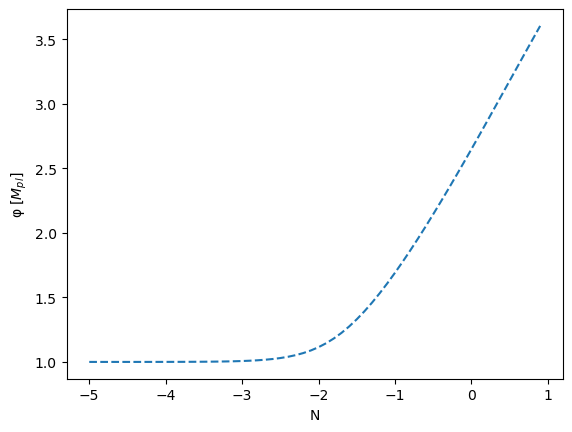

In [8]:
Nrange = np.arange(-5,1,.1)
z_values = exp(-Nrange)
Ni =0

sol = odeint(CoupledSteinhardt,[1,0],t=Nrange)
phi_sol = sol[:,0]
phi_prime = sol[:,1]

# Plot of φ vs N
plt.xlabel("N")
plt.ylabel(r"φ $[M_{pl}]$")
plt.plot(Nrange,phi_sol,'--')

In [9]:
# Other cosmological constants
def other_parameters(fi,dfi,N):
    a = exp(N) # N = ln(a)
    ai = exp(Ni)
    z = exp(-N)-1
    rho_m = rho_c0*ohm_m*(a*ai)**(-3) #1e7 is that initial pmi value
    Pot = V(M_val,fi)
    H2 = (rho_m + Pot)/(3-1/2*dfi**2)
    rho_φ = 0.5*(dfi**2*H2) + Pot #Energy density of φ (ρ_φ)
    #ratio_rho = rho_φ/rho_m
    
    O_φ = ((k**2)/3)*(rho_φ/H2) # Ωφ
    O_m = 1-O_φ
    
    Pφ = 0.5*(dfi**2*H2) - Pot
    Y_φ = (Pφ+rho_φ)/rho_φ
    w = Pφ/rho_φ #Equation of State wΦ
    weff = Pφ/(rho_φ +rho_m)
    return z,rho_φ,Pφ,O_φ,O_m,w,Y_φ,rho_m,weff

In [10]:
z,rho_s,P,O_Q,O_m,w,Y_Q,rho_m,weff = other_parameters(phi_sol,phi_prime,Nrange)
Z = z+1

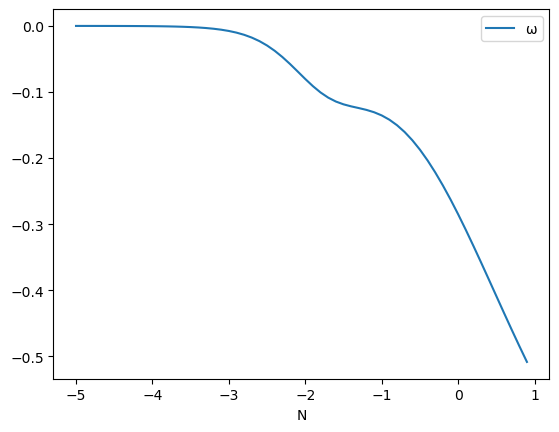

In [11]:
# Plots of cosmological constants vs N

#plt.plot(Nrange,phi_sol, label  =r"φ")
#plt.plot(Nrange,phi_prime, label  =r"φ'")
#plt.plot(Nrange,rho_s,label=r"$ρ_φ$")
#plt.plot(Nrange,rho_m,label=r"$ρ_m$",ls='--')
#plt.plot(Nrange,P,label=r"P_φ") 
#plt.plot(Nrange,O_Q,label=r"Ω_φ") 
plt.plot(Nrange,weff,label=r"ω") 
plt.xlabel("N")
#plt.xlim([-1,1])
plt.legend()
#plt.savefig(r"log of $ρ_φ$ and $ρ_m$ for Q = {}.png".format(np.round(Q,3))) 

# Evolution of 6 cosmological parameters for different $φ_i$
In the following cell we simulate the evolution of cosmological parameters over a chosen range of $N$ while changing the strength of the coupling $\beta$. We then plot the evolution of the parameters as one figure. We only show the evolution of 6 cosmological parameters and these are: the scalar field, $\phi$, the potential of the scalar field, $V(\phi)$, the effective equation of state of the field, $\omega_f$, the energy densities of the scalar field and matter ($\rho_φ$,$\rho_m$) in logarithmic scales and the fractional densities of the scalar field and matter ($\Omega_φ$, $\Omega_m$). 

Using the results from our study on normal quintessence, we choose  $φ_i = 0.9$ and  $φ_i ' = 0$. The numerical solutions of the cosmological parameters are generated inside the for loop using odeint as we did above but with different levels of coupling including no coupling. Once we have generated this data for the set range of N, we substitute φ and φ' into the other_parameters function to produce the remaining cosmological parameters. We do this for all values of $\beta$  to observe how the coupling influences the evolution of the cosmological parameters. For each $\beta$ value, each parameter is then assigned to a subplot using the function xaxis as we did for normal quintessence. 

The xaxis function takes four inputs: x, label, i, ls. x is the x-axis and so must be either Nrange or Z, where Z = z+1 and in logarithmic scales. label is where you enter the label for the x_axis. i is the same i that is in the for loop so are our values of $\beta$. ls is the linestyle of the plots. This is needed so that each coupling solution a different linestyle. 

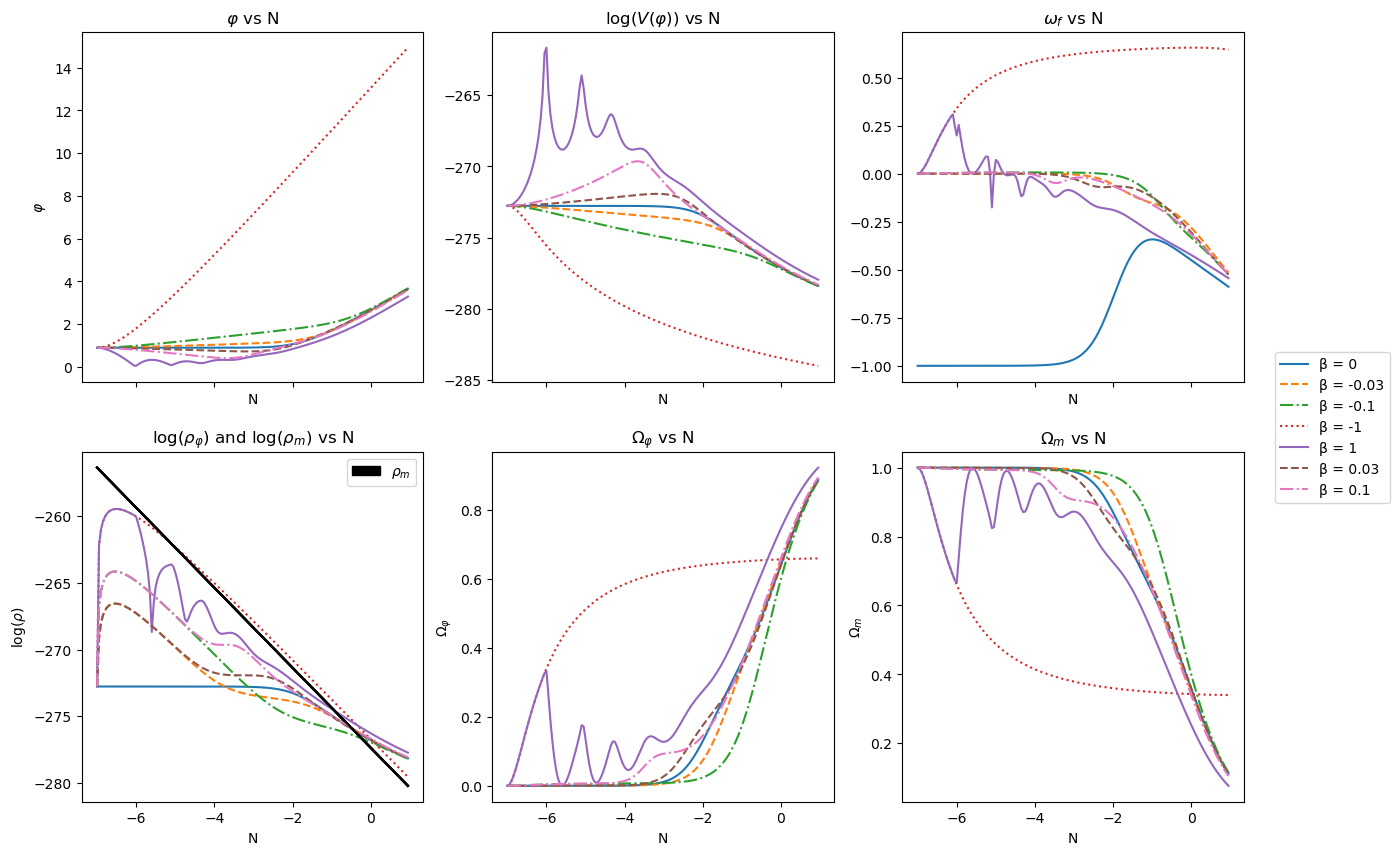

In [12]:
Nrange = np.arange(-7,1,.05)
Q_list = []
Ni = Nrange[0]
w_list = []
from itertools import cycle
StyleList = ['solid','dashed','dashdot','dotted']
cmap = ['red','blue','green']
lines = cycle(StyleList)
colours = cycle(cmap)

fig, axs = plt.subplots(2,3, figsize=(15, 10),sharex=True)
def xaxis(x,label,i,ls):        
    #axs[0,0].set_yscale('log')
    axs[0,0].plot(x,solQ[:,0],label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
    axs[0,0].set(ylabel = r"$φ$", xlabel = "{}".format(label),title=r"$φ$ vs {}".format(label))
    
    #axs[0,1].plot(x,solQ[:,1],label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
    #axs[0,1].set(ylabel = r"$φ$'$[M_{pl}]$", xlabel = "{}".format(label),title=r"$φ$' vs {}".format(label))

    axs[0,1].plot(x,log(potentials),label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
    axs[0,1].set(xlabel = "{}".format(label),title=r"log($V(φ)$) vs {}".format(label))
    
    axs[1,0].plot(x,log(rho),label=r"rho", linestyle = "{}".format(ls))
    axs[1,0].plot(x,log(rho_m),label=r"rho_m",linestyle = "solid", color = "black")
    axs[1,0].set(ylabel = r"log($ρ$)", xlabel = "{}".format(label),title=r"log($ρ_φ$) and log($ρ_m$) vs {}".format(label))
    #axs[1,0].set_xlim(-9.95,4.99)
    
    axs[1,1].plot(x,O_Q,label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
    axs[1,1].set(ylabel = r"$Ω_φ$", xlabel = "{}".format(label),title=r"$Ω_φ$ vs {}".format(label))
    #axs[1,1].set_xlim(-10,-9.)
    #axs[1,1].legend()
    
    axs[1,2].plot(x,O_m,label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
    axs[1,2].set(ylabel = r"$Ω_m$", xlabel = "{}".format(label),title=r"$Ω_m$ vs {}".format(label))
    #axs[1,2].legend()

    if i == 0:
        axs[0,2].plot(x,w,label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
        #axs[0,2].set( xlabel = "{}".format(label),title=r"ω vs {}".format(label))
    else:
        axs[0,2].plot(x,weff,label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
        axs[0,2].set( xlabel = "{}".format(label),title=r"$ω_f$ vs {}".format(label))

    #axs[0,2].plot(x,weff,label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
    #axs[0,2].set( xlabel = "{}".format(label),title=r"ω vs {}".format(label))
    #axs[0,2].legend()

    if label == "z+1":
        axs[0,0].set_xscale('log')
        axs[0,0].xaxis.set_inverted(True)
        secax0 = axs[0,0].twiny()
        secax0.set_xlim(Nrange[0],Nrange[-1])
        secax0.set_xlabel('N')
    
#Q_values = -np.arange(0,1,.1) # These are different initial values of coupling constant Q
Q_values = [0,-0.03,-0.1,-1,1,0.03,0.1]
#Q_values = [-0.03,-0.1,-1,1,0.03,0.1]
#Q_values = [0,-0.03]
#Q_values = [-1,-0.1,-0.03,0,0.03,0.1,1]
#Q_values = [0]
for i in Q_values:
    Ni = Nrange[0]
    Ni=0
    #Q_list.append("$φ_i$ = {}".format(np.round(i,4)))
    #solQ = odeint(CoupledSteinhardt,[i,0],t=Nrange)
    beta = i
    Q_list.append(r"β = {}".format(np.round(i,4)))
    solQ = odeint(CoupledSteinhardt,[.9,0],t=Nrange) # change 0.5 back to i
    potentials = (V(M_val,solQ[:,0]))
    '''When I generate solutions, I also find the corresponding z,ωφ,ρφ,Ωφ,Pφ values for all initial Q values ranged. '''
    z,rho,P,O_Q,O_m,w,Y_Q,rho_m,weff = other_parameters(solQ[:,0],solQ[:,1],Nrange)
    w_list.append((i,round(max(w),3)))
    Z = z+1
    xaxis(Nrange,"N",i,next(lines)) # Here is where you can alter whether to view graphs w.r.t to N or z+1


import matplotlib.patches as mpatches
black_patch = mpatches.Patch(color='black', label=r"$\rho_m$") # allows us to add separate legend for rho_m
axs[1,0].legend(handles=[black_patch])

fig.legend(Q_list,loc='center right')
#fig.suptitle("Plots of cosmological parameters")
fig.savefig(r"Coupled Steinhardt with ${}$ .png".format(Q_list))

The following cell uses the same code that we used above, except it only outputs a figure which displays $ρ_φ, ρ_m$ and $ω,ωf$ only. Otherwise the code executes in the same way. 

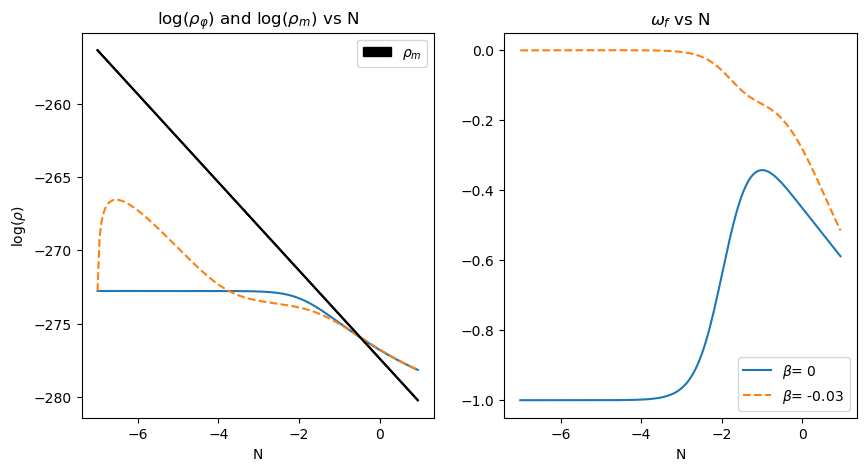

In [16]:
Nrange = np.arange(-7,1,.05)
Q_list = []
Ni = Nrange[0]
w_list = []
from itertools import cycle
StyleList = ['solid','dashed','dashdot','dotted']
cmap = ['red','blue','green']
lines = cycle(StyleList)
colours = cycle(cmap)

fig, axs = plt.subplots(1,2, figsize=(10, 5),sharex=True)
def xaxis(x,label,i,ls):        
    axs[0].plot(x,log(rho),label=r"rho", linestyle = "{}".format(ls))
    axs[0].plot(x,log(rho_m),label=r"rho_m",linestyle = "solid", color = "black")
    axs[0].set(ylabel = r"log($ρ$)", xlabel = "{}".format(label),title=r"log($ρ_φ$) and log($ρ_m$) vs {}".format(label))
    
    if i == 0:
        axs[1].plot(x,w,label=r"$\beta$= {}".format(i),linestyle = "{}".format(ls))
        #axs[0,2].set( xlabel = "{}".format(label),title=r"ω vs {}".format(label))
    else:
        axs[1].plot(x,weff,label=r"$\beta$= {}".format(i),linestyle = "{}".format(ls))
        axs[1].set( xlabel = "{}".format(label),title=r"$ω_f$ vs {}".format(label))

    # axs[1].plot(x,weff,label=r"$\beta$= {}".format(i),linestyle = "{}".format(ls))
    # axs[1].set( xlabel = "{}".format(label),title=r"ω_f vs {}".format(label))
    axs[1].legend()

    if label == "z+1":
        axs[0].set_xscale('log')
        axs[0].xaxis.set_inverted(True)
        secax0 = axs[0].twiny()
        secax0.set_xlim(Nrange[0],Nrange[-1])
        secax0.set_xlabel('N')
    
#Q_values = -np.arange(0,1,.1) # These are different initial values of coupling constant Q
Q_values = [0,-0.03,-0.1,-1,1,0.03,0.1]
#Q_values = [-0.03,-0.1,-1,1,0.03,0.1]
Q_values = [0,-0.03]
#Q_values = [-1,-0.1,-0.03,0,0.03,0.1,1]
#Q_values = [0]
for i in Q_values:
    Ni = Nrange[0]
    Ni=0
    #Q_list.append("$φ_i$ = {}".format(np.round(i,4)))
    #solQ = odeint(CoupledSteinhardt,[i,0],t=Nrange)
    beta = i
    Q_list.append(r"β = {}".format(np.round(i,4)))
    solQ = odeint(CoupledSteinhardt,[.9,0],t=Nrange) # change 0.5 back to i
    potentials = (V(M_val,solQ[:,0]))
    '''When I generate solutions, I also find the corresponding z,ωφ,ρφ,Ωφ,Pφ values for all initial Q values ranged. '''
    z,rho,P,O_Q,O_m,w,Y_Q,rho_m,weff = other_parameters(solQ[:,0],solQ[:,1],Nrange)
    w_list.append((i,round(max(w),3)))
    Z = z+1
    xaxis(Nrange,"N",i,next(lines)) # Here is where you can alter whether to view graphs w.r.t to N or z+1


import matplotlib.patches as mpatches
black_patch = mpatches.Patch(color='black', label=r"$\rho_m$") # allows us to add separate legend for rho_m
axs[0].legend(handles=[black_patch])

#fig.legend(Q_list,loc='center right')
#fig.suptitle("Plots of cosmological parameters")
fig.savefig(r"Plots of ρφ,ρm ω for Coupled Steinhardt with ${}$ .png".format(Q_list))